# 부산광역시 쓰레기 배출량 예측 pt.7

### : 23년 데이터로 test할 때의 독립변수 조합 찾기
- 연도 자체를 수치형 변수로 포함해보기 

<br>

## 00. 기본 설정 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [3]:
# 글씨 선명하게 출력하는 설정

from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

<Axes: title={'center': '한글타이틀'}>

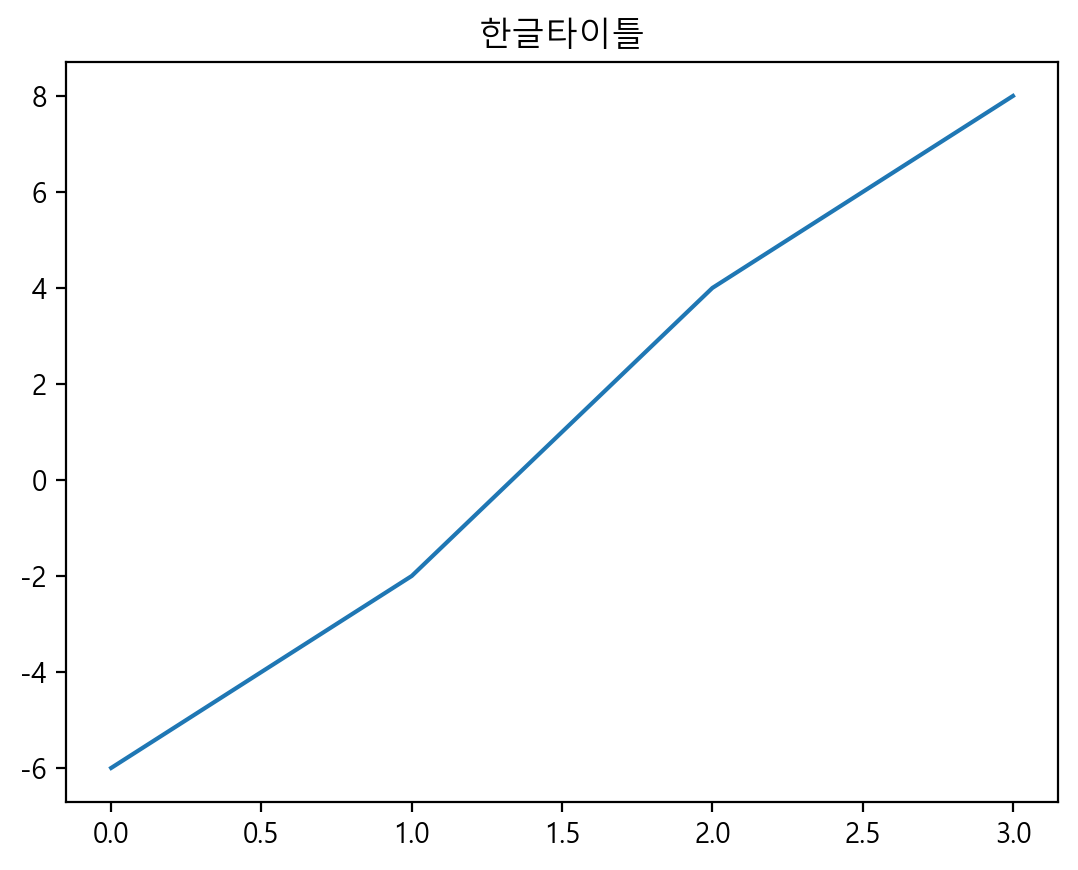

In [4]:
# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-6, -2, 4, 8]).plot(title="한글타이틀")

<br><br>

---
## 01. 데이터 불러오기

In [8]:
df = pd.read_csv("data/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


In [9]:
# 수치형 연도 변수로 변경
year_cols = [col for col in df.columns if col.startswith('연도_20')]
df['연도'] = df[year_cols].idxmax(axis=1).str.replace('연도_', '').astype(int)

df.drop(columns=year_cols, inplace=True)

print("\n--- '연도' 컬럼이 추가되고 기존 연도 컬럼이 삭제된 데이터프레임 (일부 컬럼) ---")
print(f"수정 후 shape: {df.shape}")
df[['행정구역', '연도']].head()


--- '연도' 컬럼이 추가되고 기존 연도 컬럼이 삭제된 데이터프레임 (일부 컬럼) ---
수정 후 shape: (590, 21)


,행정구역,연도
0,강원_고성군,2022
1,강원_고성군,2023
2,강원_동해시,2019
3,강원_동해시,2020
4,강원_동해시,2021


In [11]:
print("\n'연도' 컬럼의 고유 값:", df['연도'].unique())
print("'연도' 컬럼의 데이터 타입:", df['연도'].dtype)


'연도' 컬럼의 고유 값: [2022 2023 2019 2020 2021]
'연도' 컬럼의 데이터 타입: int32


<br><br>

---
## 02. 분석 목표 정의

<br>

> **종량제 방식으로 혼합 배출되었지만, '재활용' 처리된 양 예측하기**

- 혼합배출 → 분류작업 → 재활용 처리된 자원의 양
- **이중처리로 인한 추가 비용**이 발생한 자원량을 예측하는 것  

<br>

- **23년 데이터를 test** 로 놓고 예측을 한 결과, 랜덤으로 8:2 split한 결과인 `0.7074`보다 더 줄어든 `0.364`임
- 그래서 연도 데이터를 **수치형 변수** 로 놓고 다시 테스트

<br><br>

---
## 03. RandomForest 모델 test
- 로그 변환한 y값(종속변수) `log_혼합배출_후_재활용량` 쓰고
- 독립변수는 로그변환하지 않은 값을 사용할 거임

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from itertools import combinations

<br>

### 03-1. 일단 모든 변수로 변수 중요도(feature importance) 알아내기
- 연도 변수는 빼는 게 맞나??
    - '지역의 특성'만 보고 혼합배출 재활용량을 예측하고 싶다면 연도는 포함하지 않는 게 맞을듯
    - 연도 변수를 넣으면 시간의 흐름을 학습시키는 거고 미래 예측에 대한 성능은 오히려 떨어질 듯
    - **공간적인 변수**만 따지기로!

In [13]:
df.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율',
       '5인이상가구_비율', '연도'],
      dtype='object')

In [14]:
# 사용할 변수 목록
features = ['단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율',
             '1인가구_비율', '2인가구_비율', '3인가구_비율',  '4인가구_비율', '5인이상가구_비율',
             '주민등록세대수', '총인구수', '총전입', '총전출', '순이동', '연도']
target = 'log_혼합배출_후_재활용량'

# X, y 나누기
X = df[features]
y = df[target]

In [15]:
# 전체 모델로 feature importance 산출
base_model = RandomForestRegressor(n_estimators=200, random_state=42)
base_model.fit(X, y)

RandomForestRegressor(n_estimators=200, random_state=42)

In [16]:
# 중요도 순으로 정렬
importance_df = pd.DataFrame({
    'feature': features,
    'importance': base_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(f"--- 변수 중요도 정렬 --- \n{importance_df['feature'].tolist()}")

--- 변수 중요도 정렬 --- 
['총인구수', '주민등록세대수', '단독주택비율', '다세대주택비율', '2인가구_비율', '아파트비율', '연립주택비율', '5인이상가구_비율', '순이동', '총전출', '1인가구_비율', '3인가구_비율', '비주거용주택비율', '총전입', '4인가구_비율', '연도']


<br>

---
### 03-2. 임의로 선택한 변수들로 조합해서 가장 높은 R2값 만들기

In [17]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features: int,
    min_features: int,            # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features] # 선택된 핵심 피처만으로 X_all 구성
    y_all = data['log_혼합배출_후_재활용량'] # 타겟 변수 Y

    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"총 {len(selected_core_features)}개 변수 중 조합 크기 {min_features}~{max_features} 탐색 시작")

    # 연도 기준 분리
    train_data = data[data['연도'] < 2023].copy()
    test_data = data[data['연도'] == 2023].copy()

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 피처 선택
            X_train = train_data[selected_features]
            y_train = train_data['log_혼합배출_후_재활용량']
            X_test = test_data[selected_features]
            y_test = test_data['log_혼합배출_후_재활용량']

            # Random Forest 모델 학습
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최고 R2 ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['R2'].idxmax()])
    
    return results_df_sorted

In [22]:
def plot_model_performance_and_importance(results_df: pd.DataFrame):
    if results_df.empty:
        print("시각화를 할 수 없음. 데이터프레임이 없다..!")
        return

    # num_feature별로 가장 높은 R2값 정렬
    plot_data = results_df.loc[results_df.groupby('num_features')['R2'].idxmax()].reset_index(drop=True)

    # feature의 수에 상관없이 R2가 가장 높은 건 데이터프레임의 0번째 행에 있음
    best_model_row = results_df.iloc[0]
    best_r2_score = best_model_row['R2']
    best_features_combo = best_model_row['selected_features']
    best_importances = best_model_row['feature_importances']
    best_num_features = best_model_row['num_features']

    # 베스트 모델의 feature importance 데이터프레임 만들기
    best_importance_df = pd.DataFrame({
        'feature': best_features_combo,
        'importance': best_importances
    }).sort_values(by='importance', ascending=False)

    # 그래프의 크기 설정
    height_ratio_plot1 = 1.0
    height_ratio_plot2 = max(0.5, len(best_features_combo) * 0.1)

    base_figure_height = 8 
    total_figure_height_ratio = height_ratio_plot1 + height_ratio_plot2
    calculated_height = base_figure_height * (total_figure_height_ratio / 1.3)

    fig, axes = plt.subplots(2, 1, figsize=(10, calculated_height),
                             gridspec_kw={'height_ratios': [height_ratio_plot1, height_ratio_plot2]})
    fig.suptitle('모델 성능 및 피처 중요도 분석', fontsize=16, y=1.02)

    # --- Plot 1: feature의 개수에 따른 R2와 MSE ---
    ax1 = axes[0]
    ax1_2 = ax1.twinx()

    sns.lineplot(x='num_features', y='R2', data=plot_data, marker='o', color='green', ax=ax1)
    sns.lineplot(x='num_features', y='MSE', data=plot_data, marker='s', color='orange', ax=ax1_2)

    ax1.set_xlabel("Number of Features")
    ax1.set_ylabel("R2 Score", color='green')
    ax1_2.set_ylabel("Mean Squared Error (MSE)", color='orange')
    ax1.tick_params(axis='y', labelcolor='green')
    ax1_2.tick_params(axis='y', labelcolor='orange')
    ax1.set_title("R2 Score and MSE by Number of Features")
    ax1.grid(True, linestyle='--', alpha=0.3)

    lines = [
        plt.Line2D([0], [0], color='green', marker='o', label='R2 Score'),
        plt.Line2D([0], [0], color='orange', marker='s', label='MSE')
    ]
    ax1.legend(handles=lines, loc='upper right')

    # --- Plot 2: 베스트 모델의 Feature Importance ---
    ax3 = axes[1]
    sns.barplot(data=best_importance_df, x='importance', y='feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Feature Importance for Best Model (Top {best_num_features} Features, R²={best_r2_score:.4f})')
    ax3.set_xlabel('Importance')
    ax3.set_ylabel('Feature')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])

<br>

---
### test 1)

In [20]:
# feature 리스트 정의
my_selected_features_set1 = [
    '총인구수', '주민등록세대수', '아파트비율', '1인가구_비율', '순이동', '총전입', '연도'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=6
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

총 7개 변수 중 조합 크기 3~6 탐색 시작

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.0932, MSE: 1.4817

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 35/35 완료 - R2: 0.1900, MSE: 1.3236

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 21/21 완료 - R2: 0.3138, MSE: 1.1212

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 7/7 완료 - R2: 0.3023, MSE: 1.1400

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                     selected_features        R2       MSE  \
8              3                     [총인구수, 아파트비율, 연도]  0.314888  1.119491   
38             4            [총인구수, 주민등록세대수, 아파트비율, 연도]  0.340172  1.078178   
72             5   [총인구수, 주민등록세대수, 아파트비율, 1인가구_비율, 연도]  0.324417  1.103921   
96             6  [총인구수, 아파트비율, 1인가구_비율, 순이동, 총전입, 연도]  0.303633  1.137883   

                                  feature_importances  
8   [0.6906379696012773, 0.26896031454001734, 0.04...  
38  [0.46321088094448715, 0.3004261912129832, 0.20...  
72  [0.41679663231011693, 0.2662856708100805, 0.15...  
96  [0.5216104652834062, 0.12883127367064168, 0.11

,num_features,selected_features,R2,MSE,feature_importances
0,4,"[총인구수, 주민등록세대수, 아파트비율, 연도]",0.340172,1.078178,"[0.46321088094448715, 0.3004261912129832, 0.20..."
1,4,"[총인구수, 아파트비율, 1인가구_비율, 연도]",0.328251,1.097657,"[0.6219960166568509, 0.18992970148841246, 0.15..."
2,5,"[총인구수, 주민등록세대수, 아파트비율, 1인가구_비율, 연도]",0.324417,1.103921,"[0.41679663231011693, 0.2662856708100805, 0.15..."


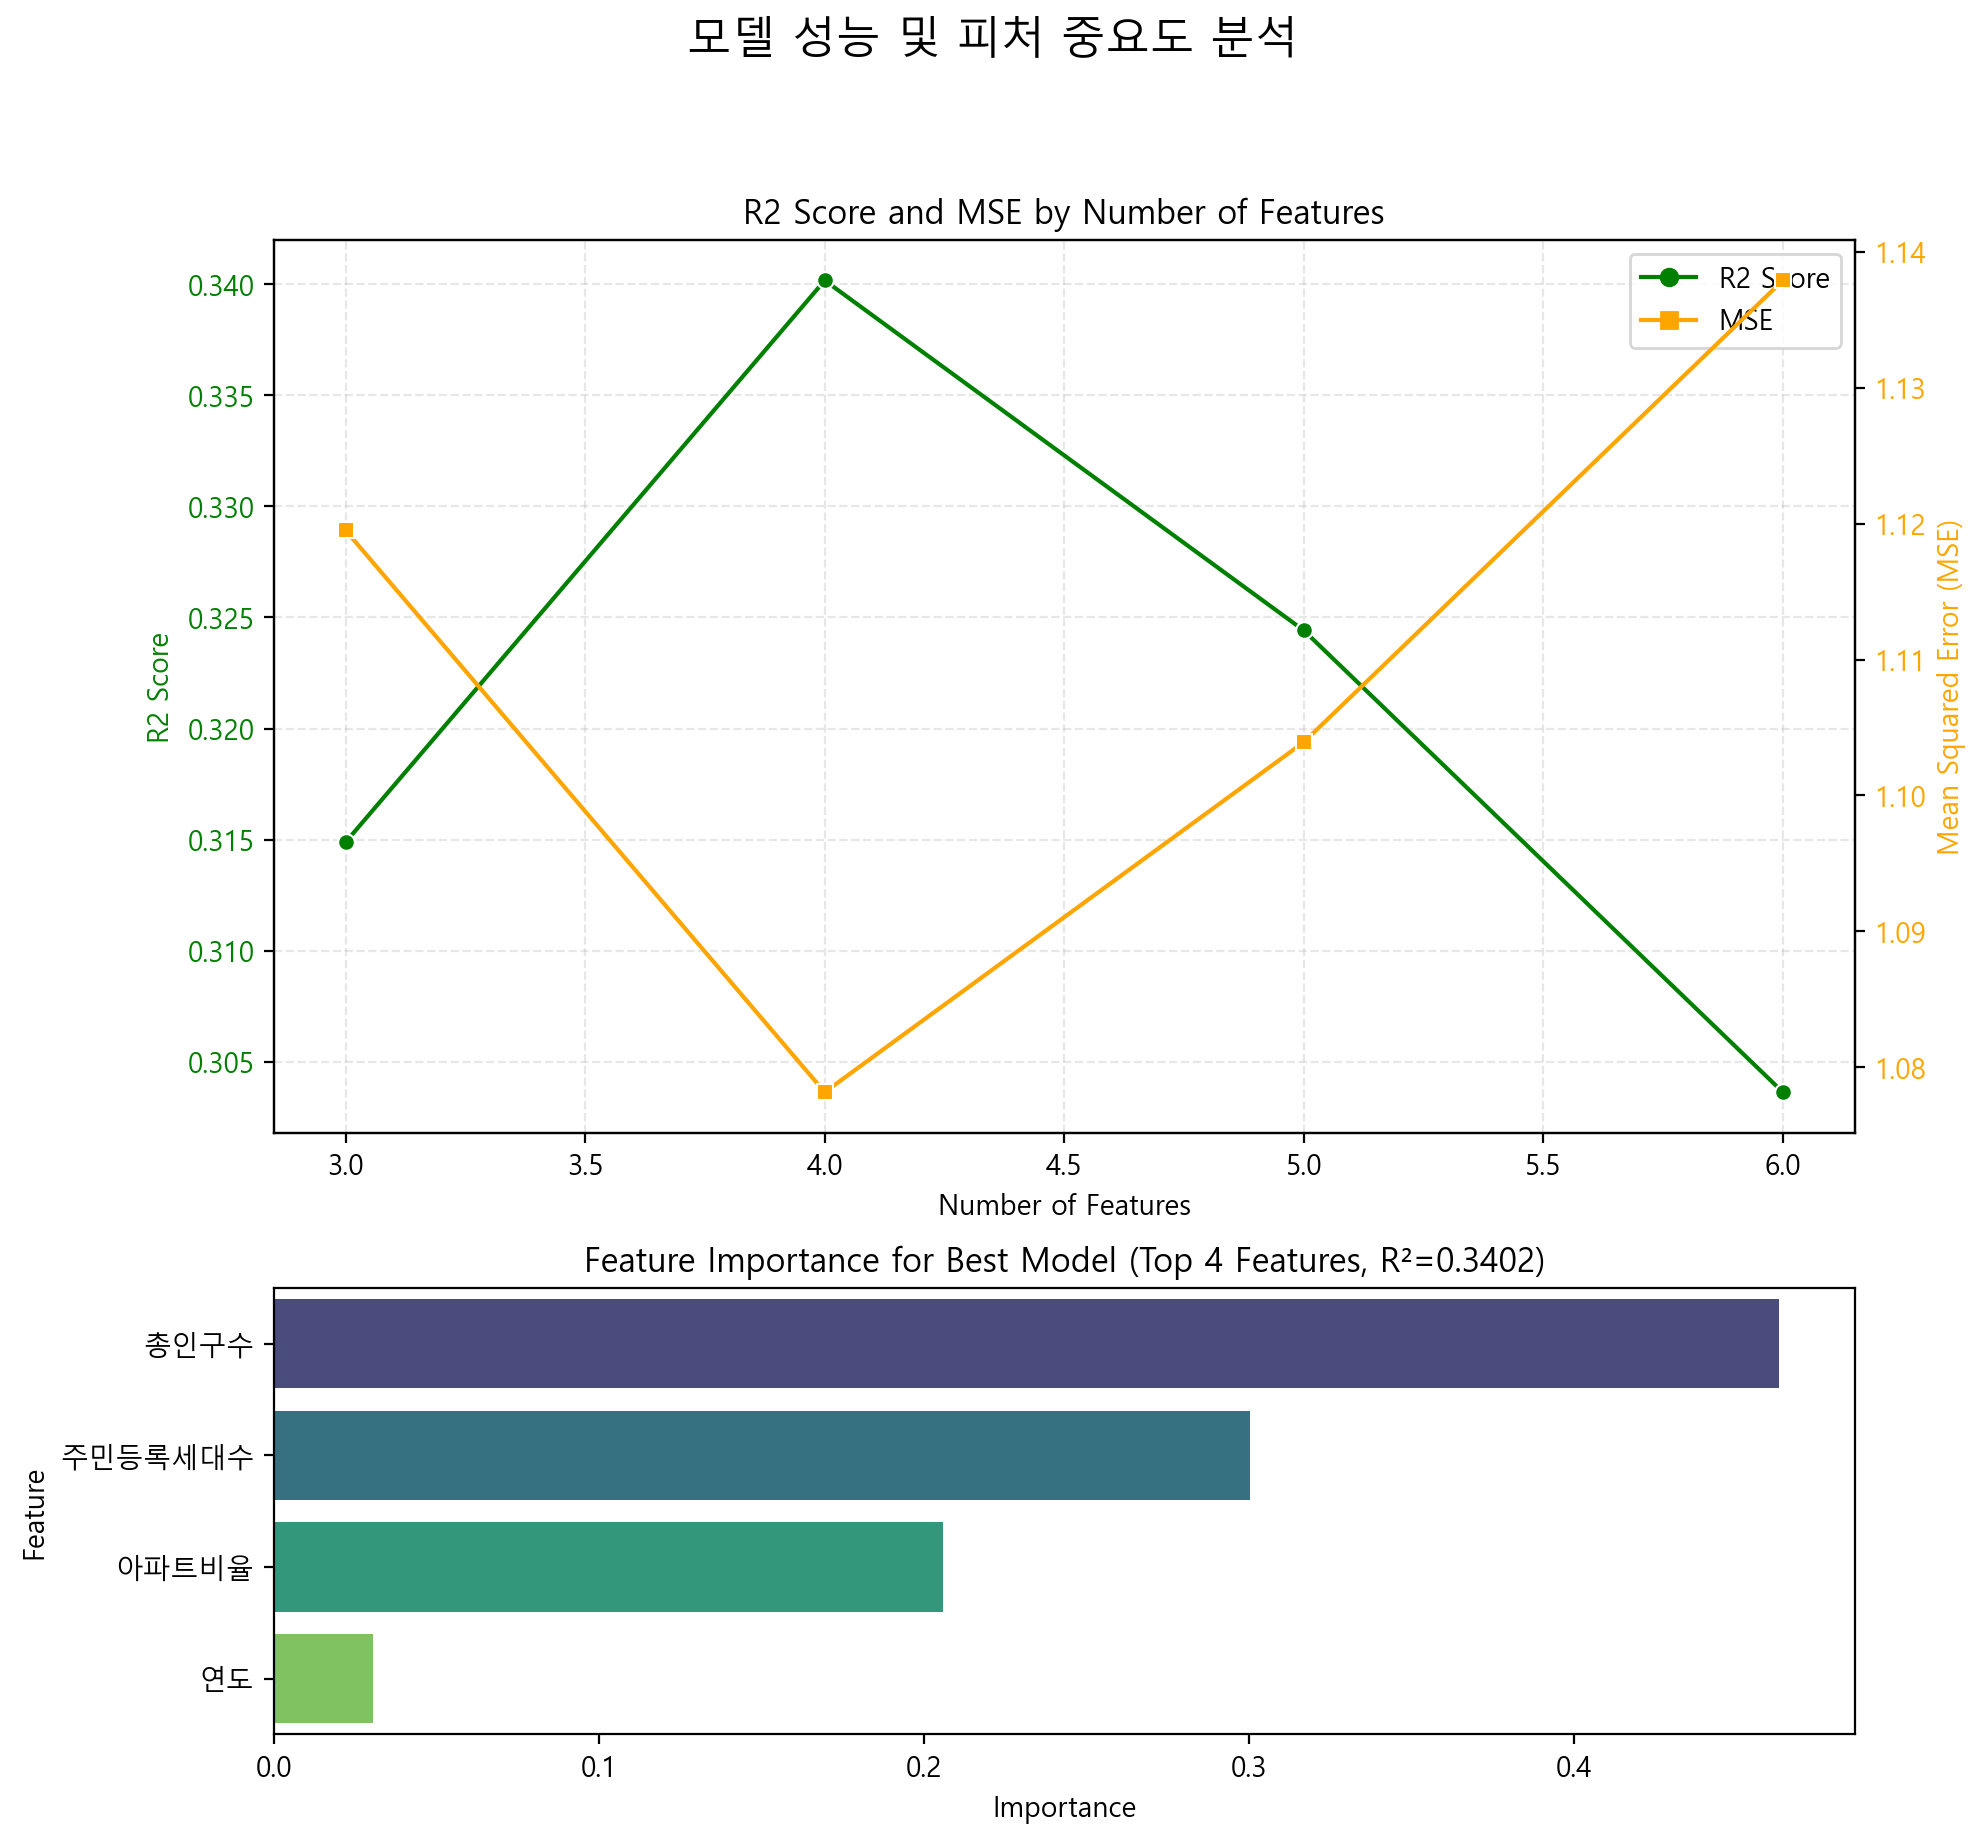

In [23]:
plot_model_performance_and_importance(results_set1)

<br>

---
### test 2)

In [26]:
my_selected_features_set2 = [
    '총인구수', '아파트비율', '단독주택비율', '5인이상가구_비율', '1인가구_비율', '연도'
]

# 함수 호출 및 결과 저장
results_set2 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set2,
    min_features=3,
    max_features=6
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set2.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

총 6개 변수 중 조합 크기 3~6 탐색 시작

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 20/20 완료 - R2: -0.2201, MSE: 1.9936

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 15/15 완료 - R2: 0.3169, MSE: 1.1162

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 6/6 완료 - R2: 0.3234, MSE: 1.1056

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.3945, MSE: 0.9894

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                              selected_features        R2  \
6              3                             [총인구수, 단독주택비율, 연도]  0.347326   
21             4                 [총인구수, 아파트비율, 단독주택비율, 1인가구_비율]  0.370851   
37             5             [총인구수, 아파트비율, 단독주택비율, 1인가구_비율, 연도]  0.398160   
41             6  [총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율, 1인가구_비율, 연도]  0.394510   

         MSE                                feature_importances  
6   1.066487  [0.6145718956243192, 0.3402923249866149, 0.045...  
21  1.028048  [0.5165201150887344, 0.13622897495107264, 0.22...  
37  0.983424  [0.5078920210309785, 0.13033039157558685, 0.21...  
41  0.989388  [0

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 아파트비율, 단독주택비율, 1인가구_비율, 연도]",0.398160,0.983424,"[0.5078920210309785, 0.13033039157558685, 0.21..."
1,6,"[총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율, 1인가구_비율, 연도]",0.394510,0.989388,"[0.4840125580571535, 0.10431800882322165, 0.19..."
2,5,"[총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율, 1인가구_비율]",0.383163,1.007929,"[0.48855844846365015, 0.1080302881483676, 0.20..."


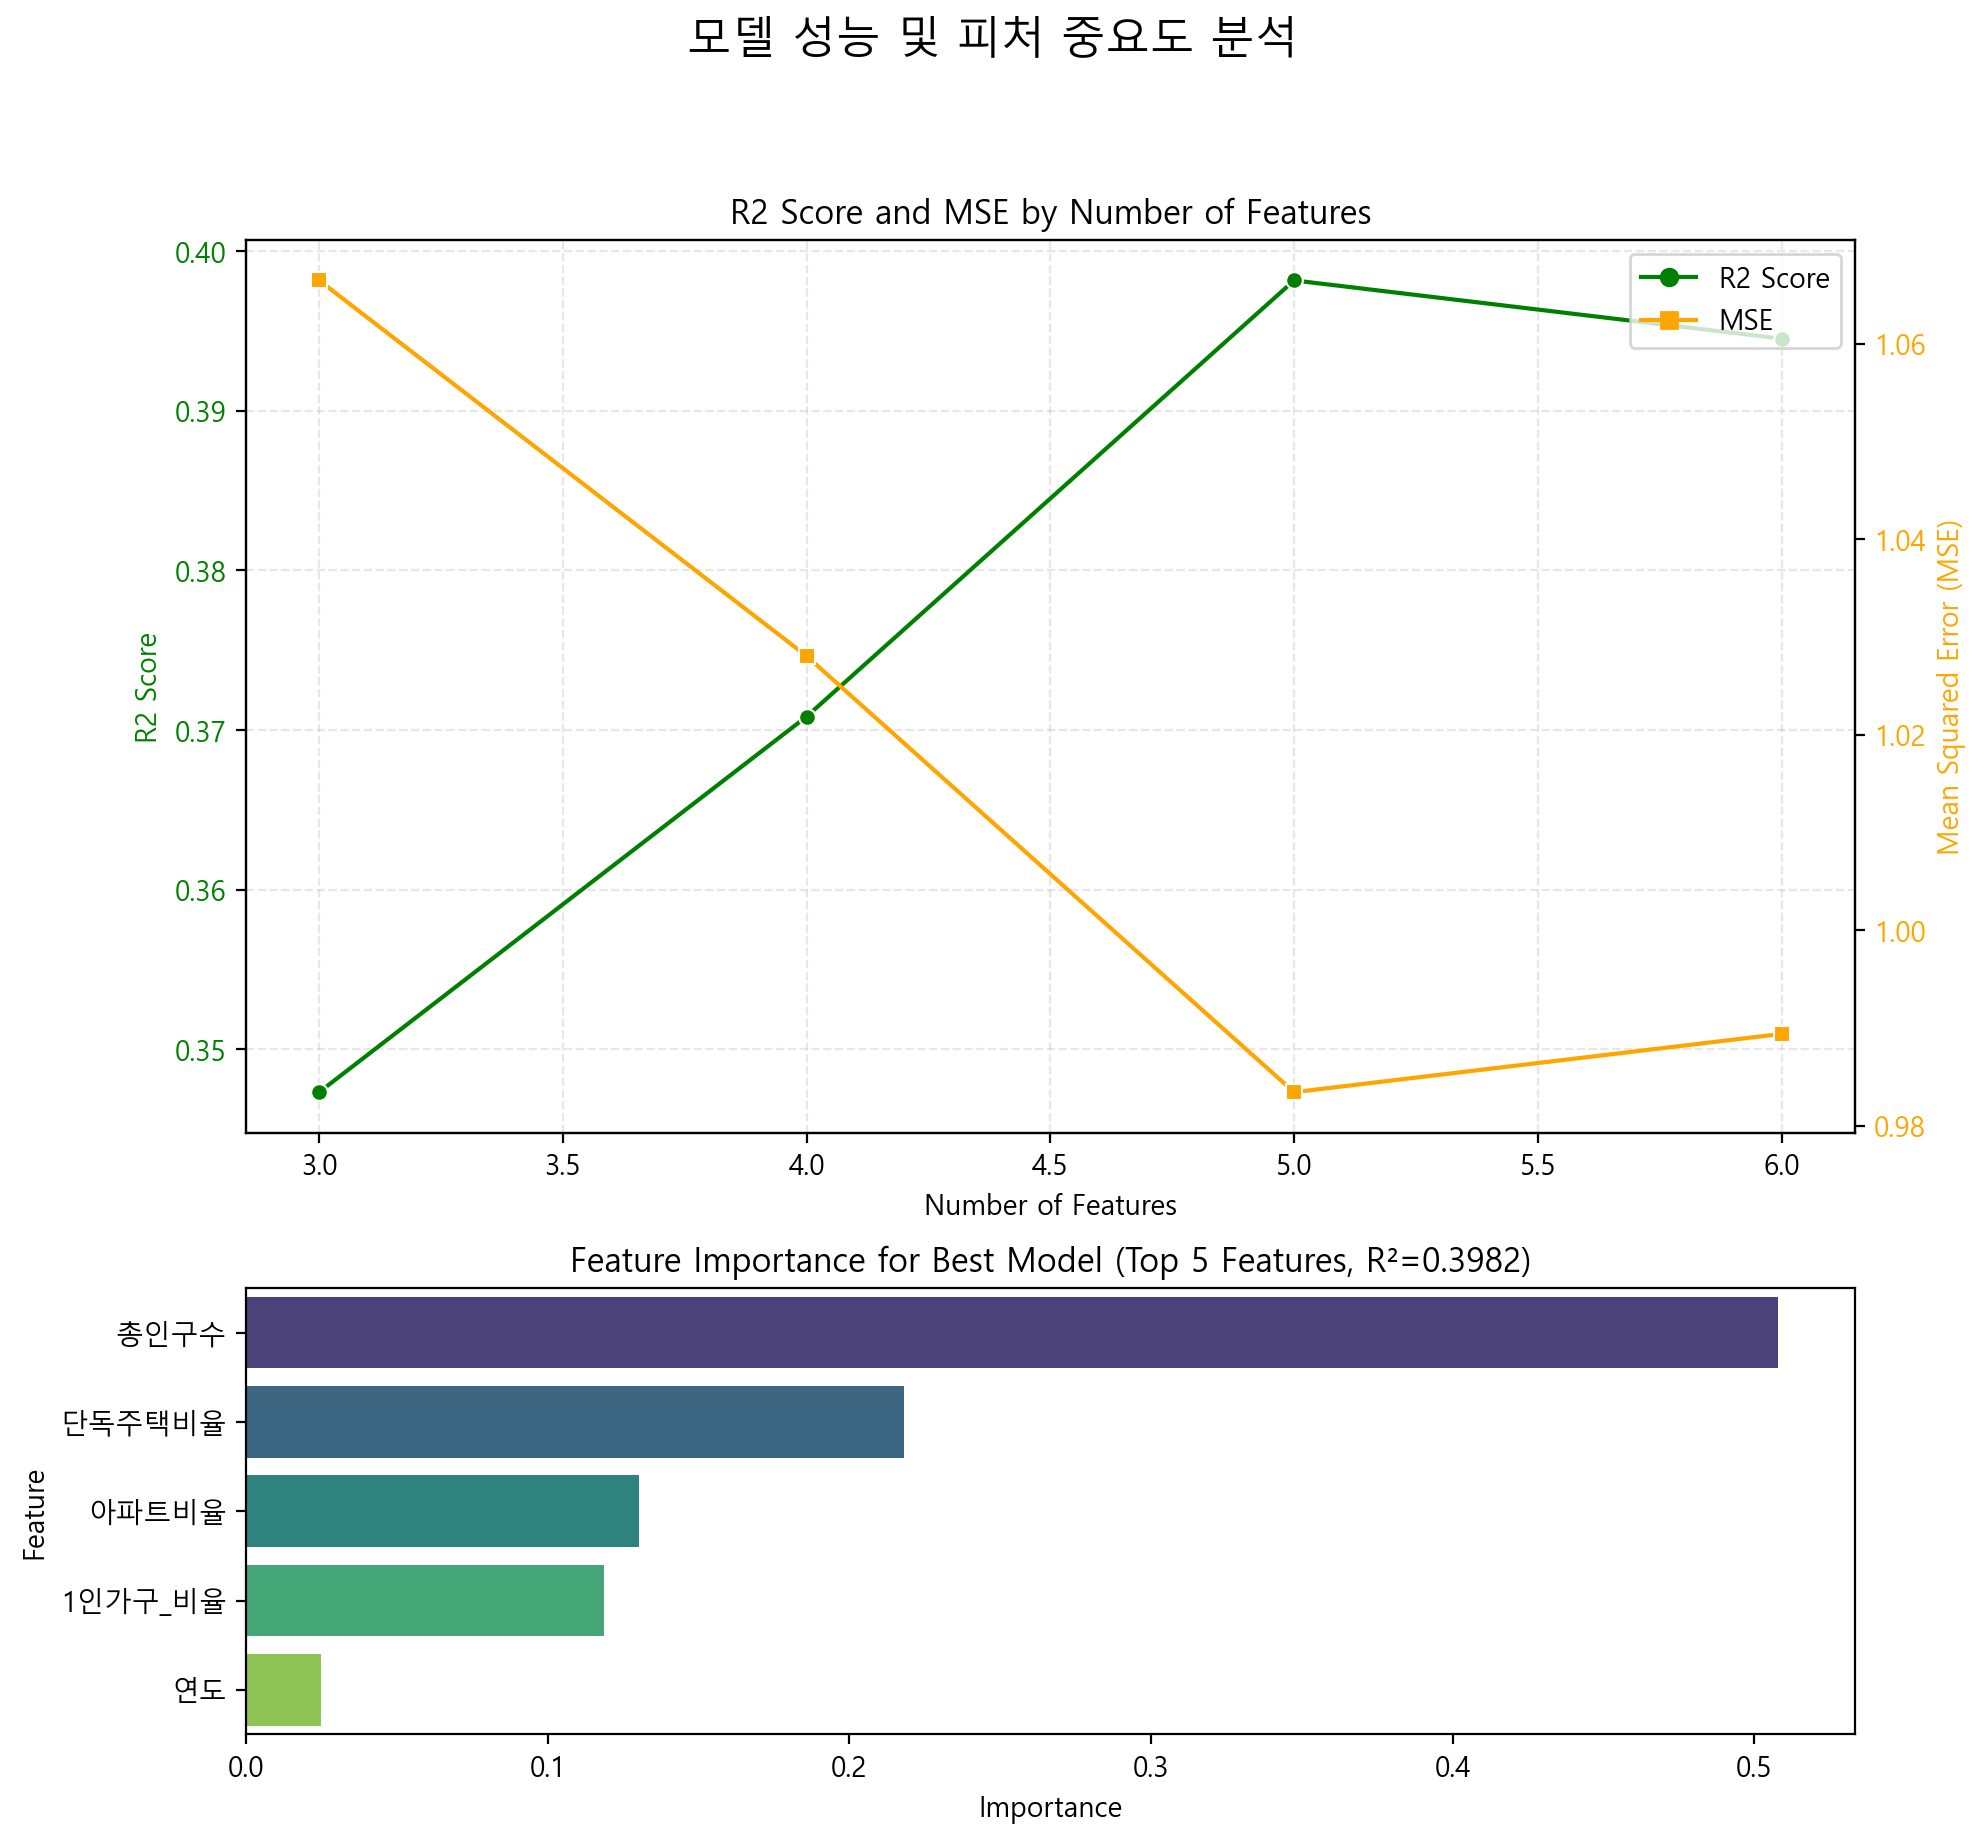

In [27]:
plot_model_performance_and_importance(results_set2)

<br>

---
### test 3)

In [29]:
my_selected_features_set3 = ['단독주택비율', '아파트비율', '다세대주택비율', '비주거용주택비율', '연도',
                             '1인가구_비율', '2인가구_비율',  '4인가구_비율', '총인구수', '총전입', '순이동']

# 함수 호출 및 결과 저장
results_set3 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set3,
    min_features=4,
    max_features=11
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set3.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

총 11개 변수 중 조합 크기 4~11 탐색 시작

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/330 완료 - R2: 0.2237, MSE: 1.2685
  > 조합 200/330 완료 - R2: 0.2600, MSE: 1.2092
  > 조합 300/330 완료 - R2: 0.2140, MSE: 1.2844
  > 조합 330/330 완료 - R2: 0.0767, MSE: 1.5087

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/462 완료 - R2: 0.3661, MSE: 1.0359
  > 조합 200/462 완료 - R2: 0.3330, MSE: 1.0899
  > 조합 300/462 완료 - R2: 0.2245, MSE: 1.2671
  > 조합 400/462 완료 - R2: 0.2778, MSE: 1.1801
  > 조합 462/462 완료 - R2: 0.2422, MSE: 1.2382

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 100/462 완료 - R2: 0.3588, MSE: 1.0478
  > 조합 200/462 완료 - R2: 0.3095, MSE: 1.1282
  > 조합 300/462 완료 - R2: 0.2895, MSE: 1.1610
  > 조합 400/462 완료 - R2: 0.3106, MSE: 1.1265
  > 조합 462/462 완료 - R2: 0.2257, MSE: 1.2652

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 100/330 완료 - R2: 0.3423, MSE: 1.0747
  > 조합 200/330 완료 - R2: 0.3046, MSE: 1.1364
  > 조합 300/330 완료 - R2: 0.3486, MSE: 1.0645
  > 조합 330/330 완료 - R2: 0.2526, MSE: 1.2213

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 100/165 완료 - R2: 0.3845, MSE: 1.0057
  > 조합

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[단독주택비율, 비주거용주택비율, 연도, 2인가구_비율, 총인구수]",0.430207,0.931058,"[0.22139541292658818, 0.10086130160661991, 0.0..."
1,6,"[단독주택비율, 다세대주택비율, 연도, 1인가구_비율, 2인가구_비율, 총인구수]",0.427908,0.934815,"[0.1852715794252011, 0.1234081577345183, 0.021..."
2,5,"[다세대주택비율, 비주거용주택비율, 연도, 2인가구_비율, 총인구수]",0.425016,0.939540,"[0.1458763494275018, 0.09253792924751986, 0.03..."


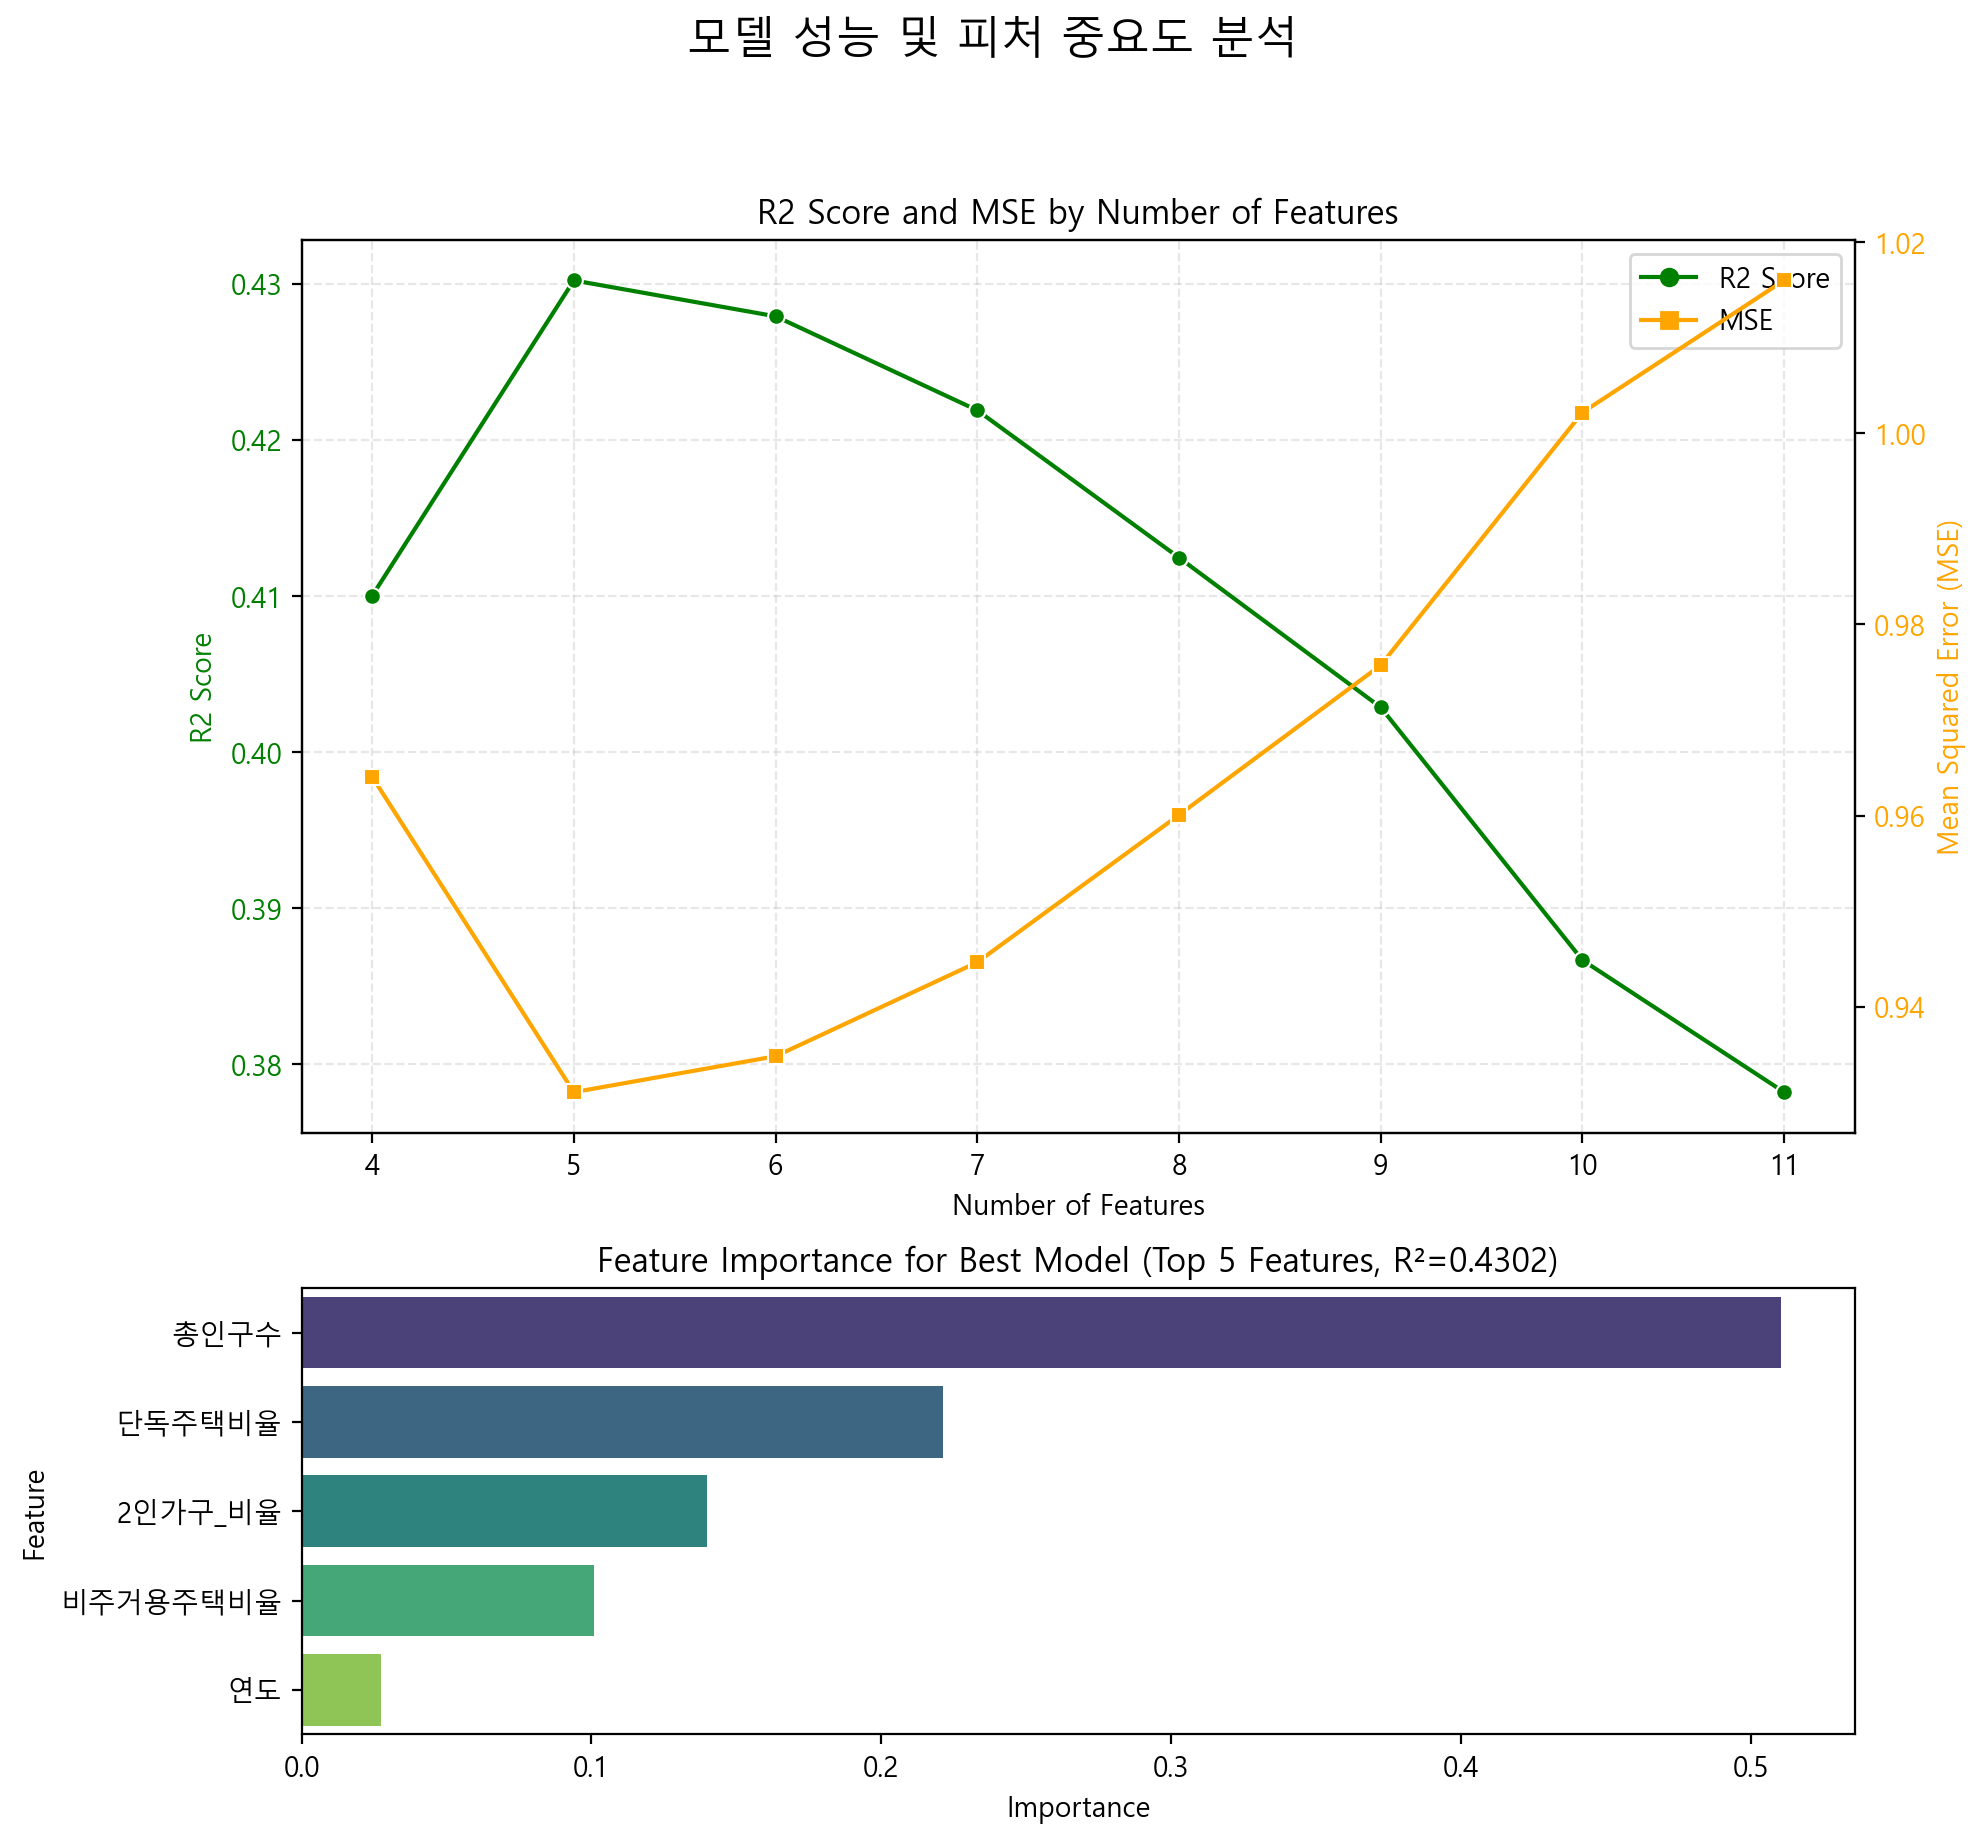

In [30]:
plot_model_performance_and_importance(results_set3)

<br>

---
### test 3) 인구 + 주거유형

In [31]:
my_selected_features_set4 = [
    '총전입', '아파트비율', '다세대주택비율', '1인가구_비율', '연도'
]

# 함수 호출 및 결과 저장
results_set4 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set4,
    min_features=3,
    max_features=5
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set4.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

총 5개 변수 중 조합 크기 3~5 탐색 시작

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.0004, MSE: 1.6333

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.2104, MSE: 1.2903

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.3458, MSE: 1.0690

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                   selected_features        R2       MSE  \
3              3             [총전입, 다세대주택비율, 1인가구_비율]  0.256761  1.214473   
10             4      [총전입, 아파트비율, 다세대주택비율, 1인가구_비율]  0.316076  1.117551   
15             5  [총전입, 아파트비율, 다세대주택비율, 1인가구_비율, 연도]  0.345795  1.068990   

                                  feature_importances  
3   [0.5573247483483548, 0.23050171571921416, 0.21...  
10  [0.4812432839463195, 0.18403849785787907, 0.17...  
15  [0.47518268810114184, 0.17326584614209345, 0.1...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총전입, 아파트비율, 다세대주택비율, 1인가구_비율, 연도]",0.345795,1.068990,"[0.47518268810114184, 0.17326584614209345, 0.1..."
1,4,"[총전입, 아파트비율, 다세대주택비율, 1인가구_비율]",0.316076,1.117551,"[0.4812432839463195, 0.18403849785787907, 0.17..."
2,4,"[총전입, 다세대주택비율, 1인가구_비율, 연도]",0.291807,1.157207,"[0.5422450435640311, 0.21364556146442232, 0.19..."


<br><br>

# 우선 여기까지